# 03 — How humans compress themselves (RQ1)

**What this notebook does (ELI5):** Step 2 gave us ~40k Reddit posts where the
author wrote their own TL;DR. Step 3 measured each post: how short is the
TL;DR, how positive/negative does each text sound, how much "I/me/my", how
many hedge words ("maybe", "I guess"), and our "summariness" score. This
notebook reads that measurements table and draws the first four candidate
figures for the website. **No heavy computation happens here** — everything
slow already lives in `data/processed/features.parquet`
(rebuild with `python scripts/03_features.py`).

Format: py:percent — open in Jupyter/VS Code as cells, or just
`python notebooks/03_explore_human_tldr.py` to regenerate all figures.

In [10]:
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

# Make the working directory the repo root, so paths work from anywhere.
# Robust ROOT: walk up from wherever we are until we find src/ or data/.
# Works when CWD is code/, code/notebooks/, or anywhere else.
def _find_root() -> Path:
    if "__file__" in dir():
        return Path(__file__).resolve().parents[1]
    for p in [Path.cwd()] + list(Path.cwd().parents):
        if (p / "src" / "tldr_audit").exists() or (p / "data" / "interim").exists():
            return p
    raise RuntimeError(
        "Cannot locate project root. Open VS Code from the code/ folder."
    )
ROOT = _find_root()
print("ROOT:", ROOT)
FIG = ROOT / "results" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

# Okabe-Ito palette: distinguishable for all common types of color blindness.
COLORS = {"political": "#D55E00", "mental_health": "#0072B2", "advice": "#009E73"}
BUCKET_LABEL = {"political": "Political debate", "mental_health": "Mental-health support",
                "advice": "Practical advice"}
ORDER = ["political", "mental_health", "advice"]

df = pd.read_parquet(ROOT / "data" / "processed" / "features.parquet")
def _classify(row):
    if row["has_question_mark"]:
        return "question"
    if row["has_joke_marker"]:
        return "reaction"
    if row["has_advice_marker"]:
        return "advice"
    if pd.notna(row["summary_novelty"]) and row["summary_novelty"] >= 0.8:
        return "reaction"
    return "summary"

df["tldr_type"] = df.apply(_classify, axis=1)
print(df["tldr_type"].value_counts())

ROOT: /home/jovyan/document_analysis_project/code


KeyError: 'has_question_mark'

## A big caveat first: posts vs. comments

The corpus contains two kinds of TL;DRs: ones under a person's own *post*
(they tell their story, then summarize it) and ones under a *comment* in a
discussion (often a reply to someone else). Political subreddits are almost
all comments; support/advice subreddits are almost all posts. Mixing them
would compare apples to oranges, so figures 1–3 use **self-posts only**.
Figure 4 uses everything, because "is this TL;DR even a summary?" applies
to both kinds.

In [3]:
posts = df[~df["is_comment"]].copy()   # self-posts only
# Drop subreddits with fewer than 100 self-posts (e.g. r/worldnews has 3):
# averaging 3 posts gives noise, not a pattern.
big_enough = posts["subreddit"].map(posts["subreddit"].value_counts()) >= 100
posts = posts[big_enough]
print("self-posts per subreddit:")
print(posts.groupby(["bucket", "subreddit"]).size())


def save(fig, name):
    """Save every figure twice: PNG for quick viewing, SVG for the website."""
    fig.savefig(FIG / f"{name}.png", dpi=200, bbox_inches="tight")
    fig.savefig(FIG / f"{name}.svg", bbox_inches="tight")
    print(f"saved {name}.png/.svg")

self-posts per subreddit:
bucket         subreddit          
advice         legaladvice            4548
               personalfinance        3493
               relationships          4963
mental_health  Anxiety                2405
               depression             4233
               offmychest             4361
political      PoliticalDiscussion     504
               politics                506
dtype: int64


## Figure 1 — How much survives the author's own TL;DR?

ELI5: if your post is 100 words and your TL;DR is 12 words, the TL;DR keeps
12% of the length. The box shows where the middle half of each community sits.
Lower = people throw away more of their own words.

saved 01_compression_by_bucket.png/.svg


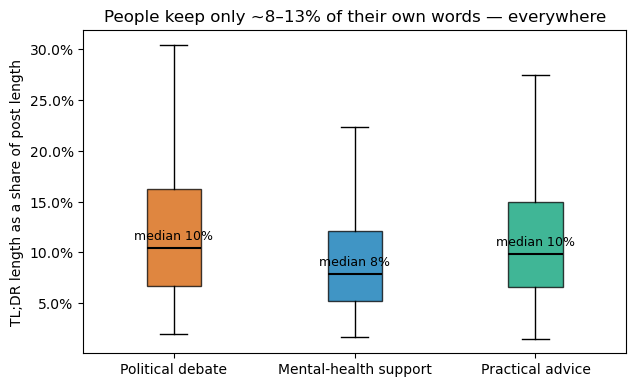

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.2))
data = [posts.loc[posts.bucket == b, "compression_ratio"].dropna() for b in ORDER]
bp = ax.boxplot(data, labels=[BUCKET_LABEL[b] for b in ORDER], showfliers=False,
                patch_artist=True, medianprops=dict(color="black", linewidth=1.5))
for patch, b in zip(bp["boxes"], ORDER):
    patch.set_facecolor(COLORS[b]); patch.set_alpha(0.75)
ax.set_ylabel("TL;DR length as a share of post length")
ax.set_title("People keep only ~8–13% of their own words — everywhere")
ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1))
for i, d in enumerate(data, start=1):
    ax.annotate(f"median {d.median():.0%}", (i, d.median()),
                textcoords="offset points", xytext=(0, 6), ha="center", fontsize=9)
save(fig, "01_compression_by_bucket")
plt.show()

## Figure 2 — What happens to the emotional tone?

ELI5: VADER gives every text a mood score from −1 (very negative) to +1
(very positive). Each arrow goes from the average mood of the *posts* to the
average mood of their *TL;DRs*. An arrow pointing right means: when people
summarize themselves, the summary sounds more positive than the full story.

saved 02_sentiment_shift_by_subreddit.png/.svg


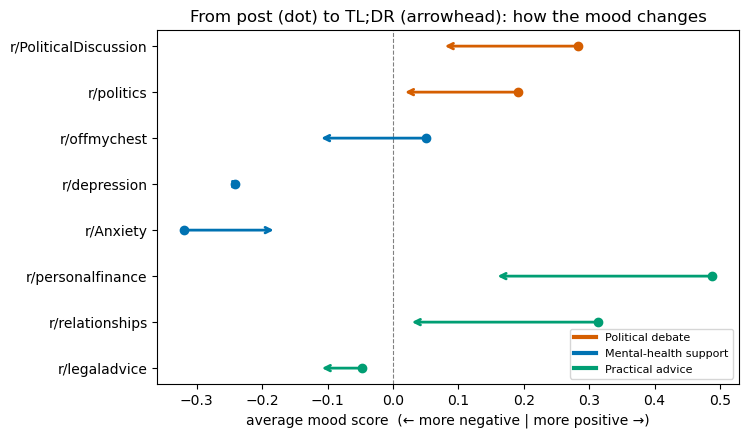

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))
subs = (posts.groupby(["bucket", "subreddit"])[["sentiment_content", "sentiment_summary"]]
        .mean().reset_index().sort_values(["bucket", "sentiment_content"]))
for y, row in enumerate(subs.itertuples()):
    c = COLORS[row.bucket]
    ax.annotate("", xy=(row.sentiment_summary, y), xytext=(row.sentiment_content, y),
                arrowprops=dict(arrowstyle="->", color=c, lw=2))
    ax.plot(row.sentiment_content, y, "o", color=c, ms=6)
ax.set_yticks(range(len(subs)))
ax.set_yticklabels("r/" + subs["subreddit"])
ax.axvline(0, color="grey", lw=0.8, ls="--")
ax.set_xlabel("average mood score  (← more negative | more positive →)")
ax.set_title("From post (dot) to TL;DR (arrowhead): how the mood changes")
handles = [plt.Line2D([], [], color=COLORS[b], lw=3, label=BUCKET_LABEL[b]) for b in ORDER]
ax.legend(handles=handles, loc="lower right", fontsize=8)
save(fig, "02_sentiment_shift_by_subreddit")
plt.show()

## Figure 3 — Does "I" survive the summary?

ELI5: we count what share of words are "I, me, my, we, us, ...". Personal
stories are full of them. The question: when people shrink their story,
do they keep talking about themselves, or does the TL;DR become impersonal?

saved 03_first_person_survival.png/.svg


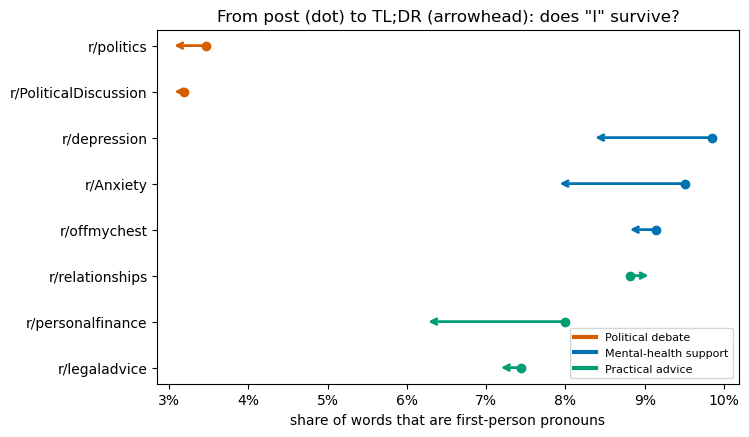

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))
subs = (posts.groupby(["bucket", "subreddit"])[["first_person_content", "first_person_summary"]]
        .mean().reset_index().sort_values(["bucket", "first_person_content"]))
for y, row in enumerate(subs.itertuples()):
    c = COLORS[row.bucket]
    ax.annotate("", xy=(row.first_person_summary, y), xytext=(row.first_person_content, y),
                arrowprops=dict(arrowstyle="->", color=c, lw=2))
    ax.plot(row.first_person_content, y, "o", color=c, ms=6)
ax.set_yticks(range(len(subs)))
ax.set_yticklabels("r/" + subs["subreddit"])
ax.set_xlabel("share of words that are first-person pronouns")
ax.xaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1, decimals=0))
ax.set_title('From post (dot) to TL;DR (arrowhead): does "I" survive?')
handles = [plt.Line2D([], [], color=COLORS[b], lw=3, label=BUCKET_LABEL[b]) for b in ORDER]
ax.legend(handles=handles, loc="lower right", fontsize=8)
save(fig, "03_first_person_survival")
plt.show()

## Figure 4 — "TL;DRs" that aren't summaries at all

ELI5: our summariness check highlights every TL;DR word that also appears in
the post. If more than 80% of a TL;DR's meaningful words are *new*, it almost
certainly isn't a summary — it's a joke, a comeback, or a brand-new thought.
This figure shows how common that is in each community. This is the
data-quality issue Jorge spotted by eye, now measured. It matters because
these cases are *human ground truth* for RQ2 only if they are real summaries.

saved 04_nonsummary_tldr_share.png/.svg


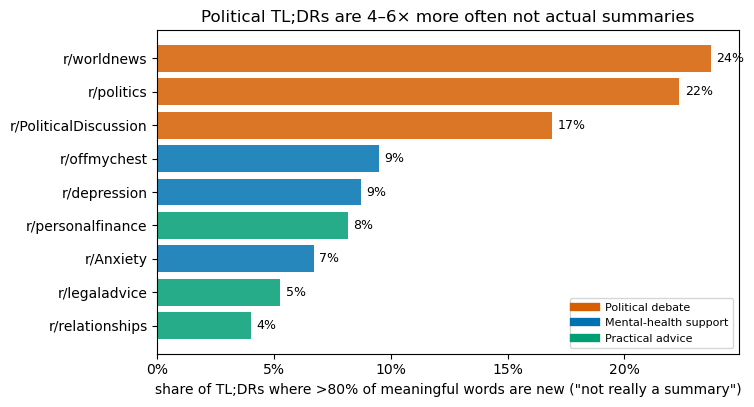

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
share = (df.assign(nonsummary=df["summary_novelty"] > 0.8)
         .groupby(["bucket", "subreddit"])["nonsummary"].mean()
         .reset_index().sort_values("nonsummary"))
bars = ax.barh("r/" + share["subreddit"], share["nonsummary"],
               color=[COLORS[b] for b in share["bucket"]], alpha=0.85)
ax.set_xlabel('share of TL;DRs where >80% of meaningful words are new ("not really a summary")')
ax.xaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1, decimals=0))
ax.set_title("Political TL;DRs are 4–6× more often not actual summaries")
for bar, v in zip(bars, share["nonsummary"]):
    ax.annotate(f"{v:.0%}", (v, bar.get_y() + bar.get_height() / 2),
                textcoords="offset points", xytext=(4, 0), va="center", fontsize=9)
handles = [plt.Line2D([], [], color=COLORS[b], lw=6, label=BUCKET_LABEL[b]) for b in ORDER]
ax.legend(handles=handles, loc="lower right", fontsize=8)
save(fig, "04_nonsummary_tldr_share")
plt.show()

## Numbers behind the figures (for the text on the website)

In [8]:
summary_table = (posts.groupby("bucket")
                 .agg(n=("id", "size"),
                      median_compression=("compression_ratio", "median"),
                      mean_sent_content=("sentiment_content", "mean"),
                      mean_sent_summary=("sentiment_summary", "mean"),
                      mean_fp_content=("first_person_content", "mean"),
                      mean_fp_summary=("first_person_summary", "mean"),
                      mean_novelty=("summary_novelty", "mean"))
                 .round(3))
summary_table.to_csv(ROOT / "results" / "tables" / "rq1_bucket_summary.csv")
print(summary_table)

                   n  median_compression  mean_sent_content  \
bucket                                                        
advice         13004               0.098              0.234   
mental_health  10999               0.079             -0.143   
political       1010               0.104              0.237   

               mean_sent_summary  mean_fp_content  mean_fp_summary  \
bucket                                                               
advice                     0.012            0.081            0.076   
mental_health             -0.172            0.095            0.084   
political                  0.045            0.033            0.030   

               mean_novelty  
bucket                       
advice                0.466  
mental_health         0.505  
political             0.579  


## Next steps
- NER survival needs spaCy's English model (runs on a normal machine, not in
  the Cowork sandbox): `python -m spacy download en_core_web_sm`, then
  rebuild features without `--no-ner`.
- Hedge rates are computed but not yet plotted — first look showed tiny
  differences; revisit after the intent labels exist.
- The "not really a summary" cases: hand-label ~300 to find out *what* they
  are (joke / reply / question / extra point) — see docs/analysis_ideas.md.

In [9]:
# %% Figure 04c — TL;DR type distribution per subreddit
# tldr_type values: "summary", "question", "advice", "reaction"
# Uses the full df (posts + comments) — type signal applies to both.

TYPE_COLORS = {
    "summary":  "#4878CF",  # blue
    "question": "#D55E00",  # orange
    "advice":   "#009E73",  # green
    "reaction": "#CC79A7",  # pink
}
TYPE_ORDER = ["summary", "question", "advice", "reaction"]

# count per subreddit x type → percentage
counts = (
    df.groupby(["bucket", "subreddit", "tldr_type"])
    .size()
    .reset_index(name="n")
)
totals = counts.groupby("subreddit")["n"].transform("sum")
counts["pct"] = counts["n"] / totals * 100

pivot = (
    counts.pivot_table(index=["bucket", "subreddit"], columns="tldr_type",
                       values="pct", fill_value=0)
    .reindex(columns=TYPE_ORDER, fill_value=0)
)
# sort by bucket order then by "summary" share descending
pivot = pivot.loc[
    [(b, s) for b in ORDER for s in df[df.bucket == b]["subreddit"].unique()]
    if True else pivot.index
]
pivot = pivot.reset_index()
pivot["sort_key"] = pivot["bucket"].map({b: i for i, b in enumerate(ORDER)})
pivot = pivot.sort_values(["sort_key", "summary"], ascending=[True, False]).drop(columns="sort_key")

fig, ax = plt.subplots(figsize=(8, 5))
subs = "r/" + pivot["subreddit"]
x = np.arange(len(subs))
bottoms = np.zeros(len(pivot))

for ttype in TYPE_ORDER:
    vals = pivot[ttype].values
    bars = ax.bar(x, vals, bottom=bottoms, label=ttype,
                  color=TYPE_COLORS[ttype], alpha=0.88)
    # label bars that are wide enough to read
    for xi, v, b in zip(x, vals, bottoms):
        if v >= 8:
            ax.text(xi, b + v / 2, f"{v:.0f}%", ha="center", va="center",
                    fontsize=7.5, color="white", fontweight="bold")
    bottoms += vals

ax.set_xticks(x)
ax.set_xticklabels(subs, rotation=40, ha="right", fontsize=8)
ax.set_ylabel("Share of TL;DRs (%)")
ax.set_ylim(0, 105)
ax.set_title("What kind of TL;DR? — type distribution by community",
             fontweight="bold", fontsize=11)
ax.legend(frameon=False, fontsize=9, loc="upper right")
ax.spines[["top", "right"]].set_visible(False)

# bucket separators
bucket_boundaries = []
prev_b = None
for i, (_, row) in enumerate(pivot.iterrows()):
    if row["bucket"] != prev_b and prev_b is not None:
        bucket_boundaries.append(i - 0.5)
    prev_b = row["bucket"]
for xb in bucket_boundaries:
    ax.axvline(xb, color="#aaa", lw=1, ls="--")

fig.tight_layout()
save(fig, "04c_tldr_type_by_subreddit")
plt.show()

KeyError: 'tldr_type'